# Соревнование по прогнозированию погоды: Эталонное решение

Добро пожаловать в разбор соревнования по прогнозированию погоды!

**Цель этого ноутбука** — наглядно показать, как можно построить мощный статистический бейзлайн, который не уступает, а иногда и превосходит сложные ML-модели, за счет внимательного анализа данных и понимания задачи.

> **Важное замечание:** В этом соревновании от нас требовалось построить именно **статистический бейзлайн**, а не ML-модель.

### Структура разбора:
1.  **Наивный подход (Baseline):** Сначала мы построим простейшую модель, которая не учитывает никаких особенностей данных. Это будет наша отправная точка.
2.  **Работа детектива (Поиск закономерностей):** Затем мы начнем исследовать данные, находить аномалии и долгосрочные тренды. Каждый найденный паттерн будет подробно объяснен: в чем его суть, как его можно было заметить и как его использовать для улучшения прогноза.
3.  **Улучшенный бейзлайн:** Мы создадим новое решение с использованием найденных закономерностей и сравним его качество с базовым.
4.  **Разбор лучшего решения с лидерборда:** Проанализируем код, который показал лучший результат в соревновании, и разберем его хитрости.
5.  **Приложение (Для любознательных):** В самом конце мы покажем код, с помощью которого генерировались данные. Это позволит заглянуть "за кулисы" и увидеть, как именно каждая из особенностей была заложена в датасет.

## Часть 1: Подготовка и наивный подход

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_SEED = 42

# Загружаем данные
# Предполагается, что файлы лежат в корневой папке
df_train_raw = pd.read_parquet("train.parquet")
df_test  = pd.read_csv("test.csv")
df_solution = pd.read_csv("solution.csv")
df_sample_sub = pd.read_csv("sample_submission.csv")

In [ ]:
df_train_raw

,timestamp,station_id,temperature,humidity,wind
0,2000-04-01 00:00:00,1,14.520706,69.998333,4.046831
1,2000-04-01 01:00:00,1,15.911492,69.998333,4.046831
2,2000-04-01 02:00:00,1,13.301754,69.998333,4.046831
3,2000-04-01 03:00:00,1,14.365540,69.998333,4.046831
4,2000-04-01 04:00:00,1,13.145509,69.998333,4.046831
...,...,...,...,...,...
6255979,2024-05-31 19:00:00,31,24.302536,60.024836,4.999833
6255980,2024-05-31 20:00:00,31,22.693778,60.024836,4.999833
6255981,2024-05-31 21:00:00,31,25.320728,60.024836,4.999833
6255982,2024-05-31 22:00:00,31,24.480543,60.024836,4.999833


### 1.1 Первый взгляд на данные и предобработка

Первое, на что стоит обратить внимание — формат данных. В `train.parquet` у нас почасовые данные, а в `test.csv` нам нужно предсказать **дневной минимум и максимум**.

Это значит, что наш первый и самый важный шаг — агрегировать обучающие данные до такого же формата: `station_id`, `date`, `min_temperature`, `max_temperature`.

In [ ]:
df_train_raw['timestamp'] = pd.to_datetime(df_train_raw['timestamp'])
df_train_raw['date'] = df_train_raw['timestamp'].dt.date

# Агрегируем почасовые данные в дневные min/max
df_train_daily = (
    df_train_raw
    .groupby(['station_id', 'date'])['temperature']
    .agg(['min', 'max'])
    .reset_index()
    .rename(columns={'min': 'min_temperature', 'max': 'max_temperature'})
)

# Добавляем фичи времени для дальнейшего анализа
df_train_daily['date'] = pd.to_datetime(df_train_daily['date'])
df_train_daily['dayofyear'] = df_train_daily['date'].dt.dayofyear
df_train_daily['year'] = df_train_daily['date'].dt.year

df_train_daily.head()

,station_id,date,min_temperature,max_temperature,dayofyear,year
0,1,2000-04-01,10.761721,22.832029,92,2000
1,1,2000-04-02,12.834382,21.108055,93,2000
2,1,2000-04-03,11.901798,22.942281,94,2000
3,1,2000-04-04,11.326481,22.939870,95,2000
4,1,2000-04-05,13.288311,24.306155,96,2000


Также для ознакомительного анализа данных будет полезно посмотреть на распределение температур по дням года, где заметна ярко выраженная цикличность:

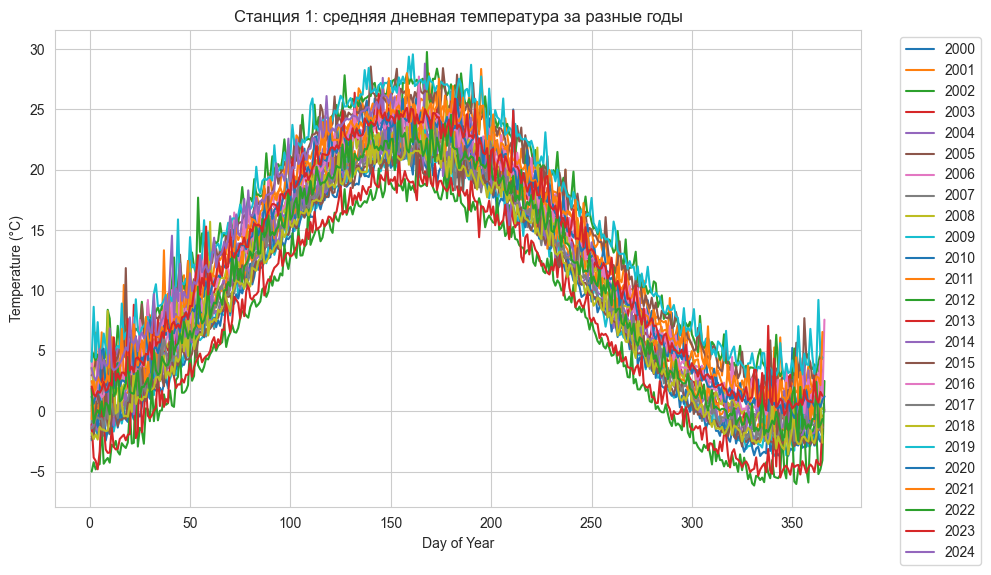

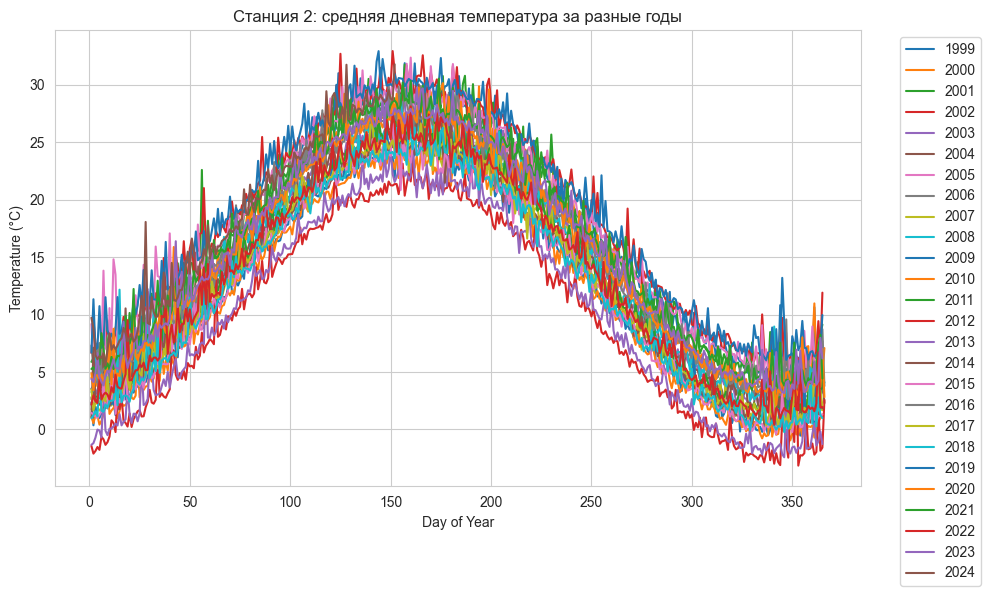

In [ ]:
# Анализ сезонности: средняя температура по дням года для каждой станции
df_train = df_train_raw # Используем исходные почасовые данные
df_train["timestamp"] = pd.to_datetime(df_train["timestamp"])  # на всякий случай
df_train["date"] = df_train["timestamp"].dt.date
df_train["year"] = df_train["timestamp"].dt.year

for i in [1, 2]:
    df_train_st1 = df_train[df_train["station_id"] == i].copy()
    df_train_st1_daily = (
        df_train_st1.groupby(["year", "date"])["temperature"]
        .mean()
        .reset_index()
    )
    df_train_st1_daily["dayofyear"] = pd.to_datetime(df_train_st1_daily["date"]).dt.dayofyear

    pivot_data = df_train_st1_daily.pivot(index="dayofyear", columns="year", values="temperature")

    plt.figure(figsize=(10, 6))
    for year in pivot_data.columns:
        plt.plot(pivot_data.index, pivot_data[year], label=str(year))
    plt.title(f"Станция {i}: средняя дневная температура за разные годы")
    plt.xlabel("Day of Year")
    plt.ylabel("Temperature (°C)")
    plt.legend(bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()

Смотря на график, можно заметить несколько вещей:
1. Вероятно, хорошим статистическим прогнозом на следующий год будет температура в тот же день в прошлый год
2. Температура испытывает колебания - то есть к синусоиде как бы добавлен некоторый шум. Это может натолкнуть на идею усреднения температур за несколько соседних дней,
3. Средняя температура от года к году меняется,
4. Средняя температура для разных станций разная.

### 1.2 Модель "без изысков" (Наивный Baseline)

Самый простой способ предсказать температуру для определенного дня года (например, 15 июня) — это посмотреть, какая температура была в этот день в прошлом, и усреднить. Здесь мы пользуемся тем фактом, что температура циклична. (Напомним, что мы не используем ML, а пытаемся сделать статистический бейзлайн).

Поскольку метрика соревнования — **MAE (Mean Absolute Error)**, оптимальным константным ответом для набора значений ground truth таргета является **медиана**. Она менее чувствительна к выбросам, чем среднее арифметическое. Мы также будем использовать ее для аггрегации значений температуры за разные годы. Можно рассматривать эту ситуацию таким образом: значения температуры на выбранную дату (например, 15 июня) за разные годы это как бы предсказания разных моделей, которые мы пытаемся объединить в "ансамбль". Если мы, например, обнаружим, что в каком-то году показатели за 15 июня имеют выбросы, это может увеличить нашу ошибку, поэтому медиана здесь более осторожна (хотя ничего и не гарантирует, что она будет лучше среднего, и среднее тоже стоит попробовать).

**Логика бейзлайна:** для каждого дня в тестовом наборе (`station_id`, `dayofyear`) мы найдем медианную минимальную и максимальную температуру по всем предыдущим годам в обучающих данных.

In [ ]:
# Готовим тестовые данные, добавляя dayofyear
df_test_base = df_test.copy()
df_test_base['timestamp'] = pd.to_datetime(df_test_base['timestamp'])
df_test_base['dayofyear'] = df_test_base['timestamp'].dt.dayofyear

# Считаем медианы по всей истории
baseline_agg = df_train_daily.groupby(['station_id', 'dayofyear']).agg(
    min_baseline=('min_temperature', 'median'),
    max_baseline=('max_temperature', 'median')
).reset_index()

# Присоединяем предсказания к тестовым данным
df_pred_base = df_test_base.merge(baseline_agg, on=['station_id', 'dayofyear'], how='left')

# Заполняем temperature в зависимости от measure_type
df_pred_base['temperature'] = np.where(
    df_pred_base['measure_type'] == 'min',
    df_pred_base['min_baseline'],
    df_pred_base['max_baseline']
)

# Считаем MAE
df_merged_base = df_pred_base.merge(df_solution, on='ID', suffixes=('_pred', '_true'))
mae_base = np.mean(np.abs(df_merged_base['temperature_pred'] - df_merged_base['temperature_true']))

print(f"MAE наивного бейзлайна: {mae_base:.4f}")

MAE наивного бейзлайна: 3.2111


Результат в районе `3.2` — это наша отправная точка. Теперь давайте попробуем ее улучшить, поискав в данных скрытые закономерности.

## Часть 2: Поиск закономерностей и улучшение модели

Теперь начинается самое интересное. Мы будем действовать как дата-детективы, исследуя данные на предмет аномалий и долгосрочных трендов.

### Закономерность №1: Долгосрочные тренды

**Суть:** Температура может испытывать долгосрочные тренды или колебания. Давайте проверим эту гипотезу.

**Как проверить:** Построить график средней температуры по годам для нескольких станций. Мы увидим, что последние годы в среднем теплее, чем годы в 2010-х. На графике ниже показана средняя дневная температура для каждой станции на протяжении всего года. Хорошо видно, что график растет после 2010, что подтверждает наличие тренда на потепление.

**Проблема для наивной модели:** Наш наивный бейзлайн усредняет данные за все годы, включая холодные 2010-е. Это приводит к тому, что наши прогнозы систематически занижены (эффект "bias-а" или смещения).

**Решение:** Есть два пути:
1.  **Использовать только свежие данные:** Вместо усреднения по всей истории, можно брать данные только за последние, скажем, 5-10 лет. Это уменьшит влияние старых, холодных лет.
2.  **Добавить сдвиг (drift):** Можно рассчитать среднюю температуру по всей истории, а затем добавить к ней поправку, которая компенсирует эти колебания. Эту поправку можно подобрать на валидации или даже просто "на глаз", посмотрев на графики. В итоге разница между средним за все время и средним за последние годы составляет примерно 3-4 градуса.

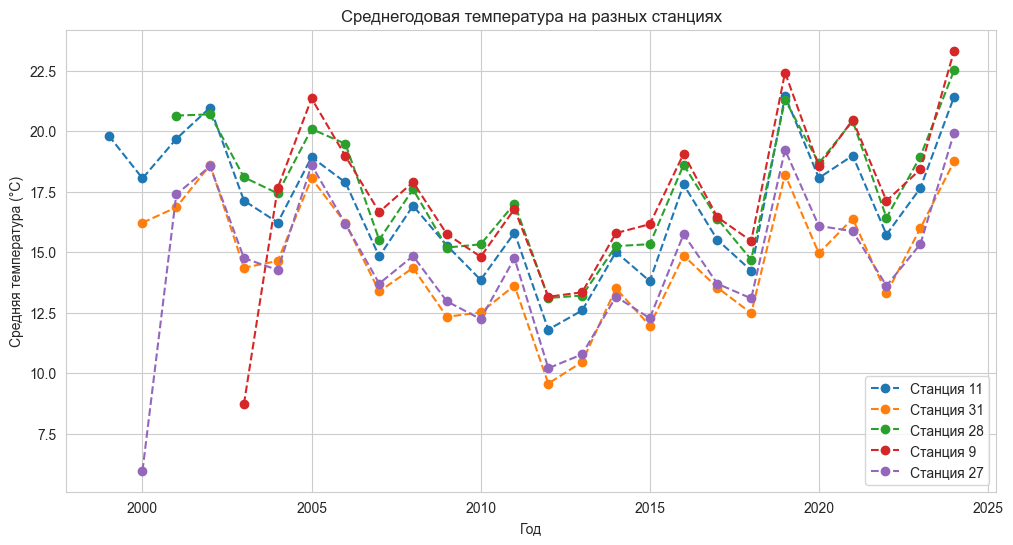

In [ ]:
plt.figure(figsize=(12, 6))

# Возьмем 5 случайных станций для примера
for station_id in np.random.choice(df_train_daily['station_id'].unique(), 5, replace=False):
    df_station = df_train_daily[df_train_daily['station_id'] == station_id]

    # Считаем среднюю температуру по годам (усредняя min и max)
    df_yearly = df_station.groupby('year').agg(
        avg_temp=('min_temperature', 'mean'),
        avg_max_temp=('max_temperature', 'mean')
    ).reset_index()
    df_yearly['avg_daily_temp'] = (df_yearly['avg_temp'] + df_yearly['avg_max_temp']) / 2

    plt.plot(df_yearly['year'], df_yearly['avg_daily_temp'], marker='o', linestyle='--', label=f'Станция {station_id}')

plt.title('Среднегодовая температура на разных станциях')
plt.xlabel('Год')
plt.ylabel('Средняя температура (°C)')
plt.grid(True)
plt.legend()
plt.show()

График наглядно показывает восходящий тренд после 2012 года. Прогнозы, основанные на данных за весь период, будут "холоднее", чем реальность 2024 года.

### Закономерность №2: Аномальные выбросы

**Суть:** В данных присутствуют экстремальные, неправдоподобные значения. Например, температура +80°C зимой или -10°C летом.

**Как найти:** Простой `df.describe()` покажет нереалистичные максимумы. Также можно построить гистограмму распределения температур, чтобы увидеть "хвосты" с выбросами.

**Почему возникает:** Ошибки в данных — обычное дело. Это могут быть сбои датчиков, ошибки при конвертации единиц измерения (например, градусы Цельсия случайно записали как Фаренгейты) и т.д.

**Проблема для модели:** Если использовать **среднее арифметическое** для агрегации, такие выбросы сильно исказят результат. Один аномальный день с температурой 80°C может значительно завысить среднее значение для этого дня года.

**Решение:** Использовать робастную к выбросам статистику. Как мы уже обсуждали, **медиана** в данном случае может оказаться лучше среднего, особенно для метрики MAE. Медиана игнорирует экстремальные значения на краях распределения.

> **Интересный момент:** Участники, которые пытались "исправить" эти аномалии (например, конвертировать Фаренгейты обратно в Цельсии), могли ухудшить свой результат. Почему? Потому что если такая же ошибка присутствует в скрытых правильных ответах (в `solution.csv`), то "исправленный" прогноз будет дальше от истины, чем прогноз, который эти аномалии игнорирует (например, с помощью медианы). В настоящих соревнованиях нужно тоже быть внимательным: если вы "исправляете" что-то в трейне, не забудьте повторить это также и на тестовых данных, если это возможно (а в данном случае это невозможно, поскольку ошибка присутствует в таргете на паблике/прайвате).

In [ ]:
df_train_daily.describe()

,station_id,date,min_temperature,max_temperature,dayofyear,year
count,260666.000000,260666,260666.000000,260666.000000,260666.000000,260666.00000
mean,15.882850,2012-10-26 11:19:16.155386624,6.742286,24.541133,182.450588,2012.32211
min,1.000000,1999-01-27 00:00:00,-15.062164,-4.231636,1.000000,1999.00000
25%,8.000000,2007-02-07 00:00:00,-1.193918,11.881128,91.000000,2007.00000
50%,16.000000,2012-11-15 00:00:00,6.464657,21.690578,182.000000,2012.00000
75%,24.000000,2018-08-21 00:00:00,14.987433,29.443189,274.000000,2018.00000
max,31.000000,2024-05-31 00:00:00,29.474919,98.573630,366.000000,2024.00000
std,9.001312,NaN,9.336049,18.061288,105.577869,6.75911


## Часть 3: Улучшенный бейзлайн

Теперь объединим наши находки и построим улучшенное решение.

**Наша стратегия:**
1.  **Агрегируем** почасовые данные в дневные `min` и `max`.
2.  **Фильтруем** исторические данные, чтобы использовать только свежую информацию (например, после 2010 года), чтобы учесть климатический сдвиг.
3.  **Считаем медиану** для каждого (`station_id`, `dayofyear`) для устойчивости к выбросам.
4.  **Добавляем константный сдвиг (drift)**, чтобы скомпенсировать потепление последних лет. Путем простого перебора или анализа графиков можно было прийти к выводу, что сдвиг в районе +4 градусов дает отличный результат.

In [ ]:
# 1. Используем уже агрегированные данные df_train_daily

# 2. Фильтруем данные, оставляя только годы после 2010
df_recent_history = df_train_daily.query('year > 2010').copy()

# 3. Считаем медиану по свежим данным
median_agg_recent = df_recent_history.groupby(['station_id', 'dayofyear']).agg(
    min_median=('min_temperature', 'median'),
    max_median=('max_temperature', 'median')
).reset_index()

# 4. Добавляем сдвиг (drift)
DRIFT_VALUE = 4.0
median_agg_recent['min_baseline'] = median_agg_recent['min_median'] + DRIFT_VALUE
median_agg_recent['max_baseline'] = median_agg_recent['max_median'] + DRIFT_VALUE

# --- Формируем предсказание для тестовых данных ---
df_test_cp = df_test.copy()
df_test_cp['timestamp'] = pd.to_datetime(df_test_cp['timestamp'])
df_test_cp['dayofyear'] = df_test_cp['timestamp'].dt.dayofyear

df_pred_cp = df_test_cp.merge(
    median_agg_recent[['station_id', 'dayofyear', 'min_baseline', 'max_baseline']],
    on=['station_id', 'dayofyear'],
    how='left'
)

df_pred_cp['temperature'] = np.where(
    df_pred_cp['measure_type'] == 'min',
    df_pred_cp['min_baseline'],
    df_pred_cp['max_baseline']
)

# Считаем итоговый MAE
df_merged_cp= df_pred_cp.merge(df_solution, on='ID', suffixes=('_pred', '_true'))
mae_cp = np.mean(np.abs(df_merged_cp['temperature_pred'] - df_merged_cp['temperature_true']))

print(f"MAE улучшенного бейзлайна: {mae_cp:.4f}")

MAE улучшенного бейзлайна: 1.3020


## Важность подбора гиперпараметров (Grid Search)

В предыдущем шаге мы использовали "магические числа": `year > 2010` и `DRIFT_VALUE = 4.0`. Такой подход, основанный на интуиции и визуальном анализе, не гарантирует оптимальности. В машинном обучении и статистическом моделировании такие настраиваемые параметры называются **гиперпараметрами**.

Чтобы найти лучшую комбинацию, мы проведем систематический перебор — **Grid Search**. Мы протестируем различные стратегии построения бейзлайна, меняя три ключевых гиперпараметра:

1.  `num_years`: **Размер исторического окна.** Вместо жесткой отсечки по году, мы будем проверять, какое количество последних лет (2, 3, 5, 10, 15 или все) дает наилучший результат.
2.  `agg_func`: **Функция агрегации.** Мы сравним `mean`, `median` и `quantile`, чтобы понять, какая статистика лучше всего справляется с выбросами и особенностями наших данных.
3.  `drift`: **Учет глобального тренда.** Мы будем включать и выключать модель коррекции климатического сдвига. Эта модель представляет собой простую **линейную регрессию**, которая учится предсказывать среднее годовое отклонение температуры от исторической нормы. Это позволяет сделать поправку на то, что 2024 год, скорее всего, будет теплее, чем средний год в нашей истории. (Обратите внимание, что этот "климатический сдвиг" не монотонен, как мы видели раньше, сначала температура падает, затем, после 2012 года, начинает возрастать; поэтому линейная модель здесь не решает проблему сама по себе, а лишь в совокупности с фильтрацией по `num_years`).

Для оценки качества каждой комбинации мы будем использовать **валидационную выборку** — данные за лето 2023 года, которые модель не видела при "обучении". Комбинация, показавшая наименьшую ошибку (MAE) на валидации, будет считаться лучшей и использоваться для финального прогноза.

In [ ]:
from sklearn.linear_model import LinearRegression
from tqdm.auto import tqdm
from IPython.display import display

# Подготовка данных для Grid Search
df_train_daily['month'] = df_train_daily['date'].dt.month

# Разделим на исторические данные (<2023) и валидационные (лето-2023)
df_train_agg_daily = df_train_daily[df_train_daily["year"]<2023].copy()
df_val_2023 = df_train_daily[(df_train_daily["year"]==2023)&(df_train_daily["month"].isin([6,7,8]))].copy()

# Переименуем колонки в df_train_agg_daily для совместимости с функциями
df_train_agg_daily.rename(columns={"min_temperature":"min_temp_daily","max_temperature":"max_temp_daily"}, inplace=True)

# Подготовим тестовые данные (df_test_truth)
df_test_truth = df_test.copy()
df_test_truth['timestamp'] = pd.to_datetime(df_test_truth['timestamp'])
df_test_truth['dayofyear'] = df_test_truth['timestamp'].dt.dayofyear
df_test_truth['year'] = df_test_truth['timestamp'].dt.year
df_test_truth = df_test_truth.merge(df_solution, on='ID')

# Агрегируем тест до daily формата
df_test_truth_min = df_test_truth[df_test_truth.measure_type=='min'].rename(columns={'temperature':'min_temperature'})
df_test_truth_max = df_test_truth[df_test_truth.measure_type=='max'].rename(columns={'temperature':'max_temperature'})
df_test_truth_copy = df_test_truth_min.merge(df_test_truth_max[['station_id', 'timestamp', 'max_temperature']], on=['station_id', 'timestamp'])
df_test_truth_copy = df_test_truth_copy[['station_id', 'min_temperature', 'max_temperature', 'timestamp', 'dayofyear', 'year']]

In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def build_global_drift_model(df_hist, agg_func, num_years, max_target_year=2024):
    """
    Строим глобальную линейную регрессию на делты (мин/макс).
    """
    df_h = df_hist.copy()
    if num_years!="all":
        cutoff = max_target_year - num_years - 1
        df_h = df_h.query("year>=@cutoff")

    def aggregator(sub):
        if len(sub)==0:
            return pd.Series({"bmin":None,"bmax":None,"ref_year":None})
        if agg_func=="mean":
            bmin = sub["min_temp_daily"].mean()
            bmax = sub["max_temp_daily"].mean()
        elif agg_func=="median":
            bmin = sub["min_temp_daily"].median()
            bmax = sub["max_temp_daily"].median()
        elif agg_func=="quantile":
            bmin = sub["min_temp_daily"].quantile(0.05)
            bmax = sub["max_temp_daily"].quantile(0.95)
        else:
            bmin,bmax=None,None
        ryear = sub["year"].mean()  # средний год выборки
        return pd.Series({"bmin":bmin,"bmax":bmax,"ref_year":ryear})

    # baseline по (station_id, dayofyear)
    df_agg = (
        df_h.groupby(["station_id","dayofyear"], as_index=False)
            .apply(aggregator, include_groups=False)
            .reset_index(drop=True)
    )

    # считаем дельты
    needed_cols = ["station_id","dayofyear","year","min_temp_daily","max_temp_daily"]
    df_h2 = df_h[needed_cols].merge(df_agg, on=["station_id","dayofyear"], how="left")
    df_h2["delta_min"] = df_h2["min_temp_daily"] - df_h2["bmin"]
    df_h2["delta_max"] = df_h2["max_temp_daily"] - df_h2["bmax"]

    df_fit = df_h2.dropna(subset=["year","delta_min","delta_max","ref_year"])
    if len(df_fit)==0:
        return None, None

    X = df_fit[["year"]].values
    y_min = df_fit["delta_min"].values
    y_max = df_fit["delta_max"].values

    reg_min = LinearRegression().fit(X, y_min)
    reg_max = LinearRegression().fit(X, y_max)
    return reg_min, reg_max

def fill_baseline_with_drift_simple(
    df_target,
    df_hist_daily,
    agg_func,
    num_years,
    drift,
    reg_min, reg_max,
    max_target_year=2024
):
    """
    Заполняем (final_min, final_max) для df_target.
    """
    df_h = df_hist_daily.copy()
    if num_years!="all":
        cutoff = max_target_year - num_years - 1
        df_h = df_h.query("year>=@cutoff")

    def aggregator(sub):
        if len(sub)==0:
            return pd.Series({"baseline_min":None,"baseline_max":None,"ref_year":None})
        if agg_func=="mean":
            bmin = sub["min_temp_daily"].mean()
            bmax = sub["max_temp_daily"].mean()
        elif agg_func=="median":
            bmin = sub["min_temp_daily"].median()
            bmax = sub["max_temp_daily"].median()
        elif agg_func=="quantile":
            bmin = sub["min_temp_daily"].quantile(0.05)
            bmax = sub["max_temp_daily"].quantile(0.95)
        else:
            bmin,bmax=None,None
        ryear = sub["year"].mean()
        return pd.Series({"baseline_min":bmin,"baseline_max":bmax,"ref_year":ryear})

    df_agg = (
        df_h.groupby(["station_id","dayofyear"], as_index=False)
            .apply(aggregator, include_groups=False)
            .reset_index(drop=True)
    )

    df_out = df_target.merge(df_agg, on=["station_id","dayofyear"], how="left")
    df_out["final_min"] = df_out["baseline_min"]
    df_out["final_max"] = df_out["baseline_max"]

    if drift and (reg_min is not None) and (reg_max is not None):
        def add_drift(row):
            if pd.isna(row["final_min"]) or pd.isna(row["ref_year"]):
                return (row["final_min"], row["final_max"])
            y_t = row["year"]
            y_r = row["ref_year"]
            offset_min, offset_max = 0, 0
            try:
                dmin_t = reg_min.predict([[y_t]])[0]
                dmin_r = reg_min.predict([[y_r]])[0]
                offset_min = dmin_t - dmin_r
            except:
                pass
            try:
                dmax_t = reg_max.predict([[y_t]])[0]
                dmax_r = reg_max.predict([[y_r]])[0]
                offset_max = dmax_t - dmax_r
            except:
                pass

            if row["final_min"] is None:
                new_min = None
            else:
                new_min = row["final_min"] + offset_min

            if row["final_max"] is None:
                new_max = None
            else:
                new_max = row["final_max"] + offset_max

            return (new_min, new_max)

        arr = df_out.apply(add_drift, axis=1)
        df_out["final_min"] = [x[0] for x in arr]
        df_out["final_max"] = [x[1] for x in arr]

    return df_out

In [ ]:
list_num_years = [2, 3, 5, 10, 15, "all"]
list_agg_func = ["mean", "median", "quantile"]
list_drift = [False, True]

results = []

for ny in tqdm(list_num_years, desc="num_years"):
    for af in tqdm(list_agg_func, desc="agg_func", leave=False):
        reg_min, reg_max = build_global_drift_model(
            df_train_agg_daily,
            agg_func=af,
            num_years=ny,
            max_target_year=2024
        )

        for drf in list_drift:
            # --- Валидация (2023) ---
            df_val_pred = fill_baseline_with_drift_simple(
                df_val_2023, df_train_agg_daily,
                agg_func=af, num_years=ny,
                drift=drf,
                reg_min=reg_min, reg_max=reg_max,
                max_target_year=2024
            )
            # Заполняем пустые значения бэкапными
            mask_none = df_val_pred["final_min"].isna() | df_val_pred["final_max"].isna()
            if mask_none.any():
                if af == "mean":
                    gmin = df_train_agg_daily["min_temp_daily"].mean()
                    gmax = df_train_agg_daily["max_temp_daily"].mean()
                elif af == "median":
                    gmin = df_train_agg_daily["min_temp_daily"].median()
                    gmax = df_train_agg_daily["max_temp_daily"].median()
                else:  # quantile
                    gmin = df_train_agg_daily["min_temp_daily"].quantile(0.05)
                    gmax = df_train_agg_daily["max_temp_daily"].quantile(0.95)
                df_val_pred.loc[mask_none, "final_min"] = gmin
                df_val_pred.loc[mask_none, "final_max"] = gmax

            val_mae_min = mae(df_val_pred["min_temperature"], df_val_pred["final_min"])
            val_mae_max = mae(df_val_pred["max_temperature"], df_val_pred["final_max"])

            # --- Тест (2024) ---
            df_test_pred = fill_baseline_with_drift_simple(
                df_test_truth_copy, df_train_agg_daily,
                agg_func=af, num_years=ny,
                drift=drf,
                reg_min=reg_min, reg_max=reg_max,
                max_target_year=2024
            )
            mask_none2 = df_test_pred["final_min"].isna() | df_test_pred["final_max"].isna()
            if mask_none2.any():
                if af == "mean":
                    gmin = df_train_agg_daily["min_temp_daily"].mean()
                    gmax = df_train_agg_daily["max_temp_daily"].mean()
                elif af == "median":
                    gmin = df_train_agg_daily["min_temp_daily"].median()
                    gmax = df_train_agg_daily["max_temp_daily"].median()
                else:  # quantile
                    gmin = df_train_agg_daily["min_temp_daily"].quantile(0.05)
                    gmax = df_train_agg_daily["max_temp_daily"].quantile(0.95)
                df_test_pred.loc[mask_none2, "final_min"] = gmin
                df_test_pred.loc[mask_none2, "final_max"] = gmax

            test_mae_min = mae(df_test_pred["min_temperature"], df_test_pred["final_min"])
            test_mae_max = mae(df_test_pred["max_temperature"], df_test_pred["final_max"])

            # Сохраняем метрики
            results.append({
                "num_years": ny,
                "agg_func": af,
                "drift": drf,
                "val_mae_min": val_mae_min,
                "val_mae_max": val_mae_max,
                "test_mae_min": test_mae_min,
                "test_mae_max": test_mae_max
            })

# Сохранение итоговых результатов
results_df = pd.DataFrame(results)
results_df["val_mae"] = 0.5 * (results_df["val_mae_min"] + results_df["val_mae_max"])
results_df["test_mae"] = 0.5 * (results_df["test_mae_min"] + results_df["test_mae_max"])

print("Результаты подбора гиперпараметров:")
display(results_df.sort_values("val_mae").head(20))

num_years:   0%|          | 0/6 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

agg_func:   0%|          | 0/3 [00:00<?, ?it/s]

Результаты подбора гиперпараметров:


,num_years,agg_func,drift,val_mae_min,val_mae_max,test_mae_min,test_mae_max,val_mae,test_mae
27,15,median,True,4.121948,5.775545,2.245109,1.515685,4.948747,1.880397
21,10,median,True,4.114063,6.278934,1.441336,1.418672,5.196499,1.430004
32,all,median,False,4.768453,6.238283,3.728622,2.915110,5.503368,3.321866
15,5,median,True,4.629480,6.488484,2.912026,2.491498,5.558982,2.701762
14,5,median,False,4.655412,6.499822,3.026441,2.643218,5.577617,2.834830
20,10,median,False,4.949294,6.480069,3.984801,3.201074,5.714682,3.592937
33,all,median,True,5.167527,6.747028,4.349019,3.601717,5.957277,3.975368
26,15,median,False,5.215764,6.826879,4.354667,3.622384,6.021322,3.988525
8,3,median,False,4.940662,7.333777,3.293677,3.696874,6.137219,3.495276
9,3,median,True,5.749107,8.574540,5.712543,6.528781,7.161824,6.120662


> Обратите внимание: колонка test_mae посчитана на тестовых данных. Это помогает нам понять, что было бы, если бы мы сабмитили такие решения и сравнить скор с валидацией. Если вы будете перезапускать ноутбук, то закомментируйте использование тестовых данных (или перегенерите датасет используя код внизу).

Grid Search показал, что лучшая комбинация на валидации — это:
1. Использование **медианы** (`median`) (потому что мы не фильтровали выбросы)
2. За последние **15 лет** (`num_years=15`) с включенной **коррекцией на дрифт** (`drift=True`). Эти параметры работают в связке, и мы уже обсудили выше, почему так лучше.

Предлагаю вам посмотреть на результаты перебора и попробовать найти другие закономерности, которые вы можете объяснить с помощью данных (возможно для этого вам придется разобраться в коде, который использовался для этого перебора).

Ручное решение, которое мы построили выше, имеет лучший скор по сравнению с жадным перебором. Это обсусловлено, конечно, негибкостью этого перебора. Однако часто перебор помогает нам лучше понять данные / найти хорошую начальную точку, с которой нужно стартовать.

Теперь, при желании, мы можем применить лучшую комбинацию по валидации для построения финального прогноза на тестовых данных.

In [ ]:
# Находим лучшие параметры по валидационной метрике
best_params = results_df.loc[results_df['val_mae'].idxmin()]
BEST_NY = best_params['num_years']
BEST_AF = best_params['agg_func']
BEST_DRF = best_params['drift']

print(f"Используем num_years: {BEST_NY}, agg_func: '{BEST_AF}', drift: {BEST_DRF}")

# Теперь используем ВСЕ доступные данные до 2024 года для построения финальной модели
reg_min_final, reg_max_final = build_global_drift_model(
    df_train_agg_daily,
    agg_func=BEST_AF,
    num_years=BEST_NY,
    max_target_year=2024
)

df_pred_tuned = fill_baseline_with_drift_simple(
    df_test_truth_copy, df_train_agg_daily,
    agg_func=BEST_AF, num_years=BEST_NY,
    drift=BEST_DRF,
    reg_min=reg_min_final, reg_max=reg_max_final,
    max_target_year=2024
)

# Заполняем пропуски
mask_none_final = df_pred_tuned["final_min"].isna() | df_pred_tuned["final_max"].isna()
if mask_none_final.any():
    gmin = df_train_agg_daily["min_temp_daily"].median()
    gmax = df_train_agg_daily["max_temp_daily"].median()
    df_pred_tuned.loc[mask_none_final, "final_min"] = gmin
    df_pred_tuned.loc[mask_none_final, "final_max"] = gmax

# Готовим submission
df_min_part = df_pred_tuned[["station_id","timestamp","final_min"]].rename(columns={"final_min":"temperature"})
df_min_part["measure_type"] = "min"
df_max_part = df_pred_tuned[["station_id","timestamp","final_max"]].rename(columns={"final_max":"temperature"})
df_max_part["measure_type"] = "max"
df_pred_long = pd.concat([df_min_part, df_max_part], ignore_index=True)

# ИСПРАВЛЕНИЕ: Приводим столбец 'timestamp' в df_test к типу datetime, чтобы он совпадал с типом в df_pred_long
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])

df_submit_tuned = df_test.merge(df_pred_long, on=["station_id","timestamp","measure_type"], how="left")

# Считаем итоговый MAE
df_merged_tuned = df_submit_tuned.merge(df_solution, on='ID', suffixes=('_pred', '_true'))
mae_tuned = np.mean(np.abs(df_merged_tuned['temperature_pred'] - df_merged_tuned['temperature_true']))

print(f"MAE бейзлайна после Grid Search: {mae_tuned:.4f}")

Используем num_years: 15, agg_func: 'median', drift: True
MAE бейзлайна после Grid Search: 1.8804


## Часть 4: Разбор лучшего решения с лидерборда

Давайте разберем решение Артинеона (Артёма Каштымова) с запуска курса в январе 2025 года (топ-1 на лб).

Этот подход развивает идеи, которые мы обсудили выше, но использует более продвинутые методы очистки данных и прогнозирования. Основная идея — **сглаживание**: вместо того, чтобы предсказывать температуру для 15 июня только на основе данных за 15 июня, модель также смотрит на соседние дни (14 и 16 июня) и усредняет их. Это делает прогноз более устойчивым к случайным колебаниям.

### Шаг 1: Продвинутая очистка от выбросов

Вместо того, чтобы просто использовать медиану по дню, автор сначала очищает *почасовые* данные. Для каждого часа, месяца, года и станции вычисляется медианная температура. Затем все значения, которые отклоняются от этой часовой медианы более чем на 10 градусов, удаляются как выбросы. Только после этой чистки данные агрегируются в дневные `min` и `max`.

In [ ]:
train_df = pd.read_parquet("train.parquet").sort_values(by='timestamp').reset_index()
train_df['date'] = train_df.timestamp.map(lambda x: str(x)[:-9])
train_df['year'] = train_df.timestamp.dt.year
train_df['month'] = train_df.timestamp.dt.month
train_df['day'] = train_df.timestamp.dt.day
train_df['hour'] = train_df.timestamp.dt.hour
train_df = train_df[train_df.year >= 2000].copy()

# Создаем ключ для каждой уникальной комбинации: год, месяц, станция, час
train_df['group_with_year'] = train_df['year'].astype(str) + '_' + train_df['month'].astype(str) + '_' + train_df['station_id'].astype(str) + '_' + train_df['hour'].astype(str)

# Находим часовую медиану для каждой группы
train_df['median_group_with_year_temperature'] = train_df.group_with_year.map(train_df.groupby('group_with_year').temperature.median())

# Считаем отклонение и удаляем выбросы
train_df['deviation'] = (train_df['temperature'] - train_df['median_group_with_year_temperature']).abs()
new_train = train_df[train_df.deviation < 10].groupby(['date', 'station_id']).temperature.agg(['max', 'min']).reset_index()

# Готовим финальный ключ для агрегации: станция, месяц, день
new_train['year'] = new_train.date.map(lambda x:x.split('-')[0]).astype(int)
new_train['month'] = new_train.date.map(lambda x:x.split('-')[1]).astype(int)
new_train['day'] = new_train.date.map(lambda x:x.split('-')[2]).astype(int)
new_train['group'] = new_train.station_id.astype(str) + '_' + new_train['month'].astype(str) + '_' + new_train['day'].astype(str)

new_train

,date,station_id,max,min,year,month,day,group
0,2000-01-01,2,8.613147,-3.240369,2000,1,1,2_1_1
1,2000-01-01,8,4.744765,-3.065320,2000,1,1,8_1_1
2,2000-01-01,10,8.450416,-5.643014,2000,1,1,10_1_1
3,2000-01-01,11,8.018478,-1.686953,2000,1,1,11_1_1
4,2000-01-01,16,9.237138,-2.623037,2000,1,1,16_1_1
...,...,...,...,...,...,...,...,...
259315,2024-05-31,27,30.060805,22.173200,2024,5,31,27_5_31
259316,2024-05-31,28,37.542450,21.557540,2024,5,31,28_5_31
259317,2024-05-31,29,34.969664,24.021110,2024,5,31,29_5_31
259318,2024-05-31,30,37.585843,25.075439,2024,5,31,30_5_31


### Шаг 2: Прогнозирование со сглаживанием

Это самая интересная часть. Прогноз для каждого дня формируется как среднее из трех предсказаний:
1.  Прогноз на основе исторических данных за **этот же день**.
2.  Прогноз на основе исторических данных за **следующий день**.
3.  Прогноз на основе исторических данных за **предыдущий день**.

Такой подход помогает сгладить случайный шум и делает модель более стабильной.

**Другие особенности:**
- **Среднее вместо медианы:** После тщательной очистки данных автор использует `mean()` для агрегации, что может быть более точным, если выбросов действительно нет.
- **Раздельный сдвиг (Drift):** Для `min` и `max` температур подобраны разные константы сдвига (`3.1` и `3.0`), что отражает возможное разное влияние потепления на ночные и дневные температуры.

In [ ]:
test = pd.read_csv("test.csv")
submit = pd.read_csv("sample_submission.csv")

# Подготовка фичей для тестовых данных
test['month'] = test.timestamp.map(lambda x:x.split('-')[1]).astype(int)
test['day'] = test.timestamp.map(lambda x:x.split()[0].split('-')[2]).astype(int)

# Подбираем сдвиги для min и max температур
shift_2024_max = 3.0
shift_2024_min = 3.1

# Считаем исторические средние по очищенным данным
mean_max_in_groups = new_train.groupby('group')['max'].mean()
mean_min_in_groups = new_train.groupby('group')['min'].mean()

# --- 1. Прогноз для текущего дня ---
test['group'] = test.station_id.astype(str) + '_' + test['month'].astype(str) + '_' + test['day'].astype(str)
submit['temperature'] = (test.measure_type == 'max') * (test.group.map(mean_max_in_groups) + shift_2024_max) + \
                        (test.measure_type == 'min') * (test.group.map(mean_min_in_groups) + shift_2024_min)

# --- 2. Прогноз на основе следующего дня (с обработкой конца месяца) ---
next_day_logic = (test['day'] + ((test['day'] != 31) * test['month'].isin([7, 8]) + (test['day'] != 30) * (test['month'] == 6)))
test['group'] = test.station_id.astype(str) + '_' + test['month'].astype(str) + '_' + next_day_logic.astype(str)
submit['temperature'] += ((test.measure_type == 'max') * (test.group.map(mean_max_in_groups) + shift_2024_max) + \
                         (test.measure_type == 'min') * (test.group.map(mean_min_in_groups) + shift_2024_min))

# --- 3. Прогноз на основе предыдущего дня (с обработкой начала месяца) ---
prev_day_logic = (test['day'] - (test['day'] != 1))
test['group'] = test.station_id.astype(str) + '_' + test['month'].astype(str) + '_' + prev_day_logic.astype(str)
submit['temperature'] += ((test.measure_type == 'max') * (test.group.map(mean_max_in_groups) + shift_2024_max) + \
                         (test.measure_type == 'min') * (test.group.map(mean_min_in_groups) + shift_2024_min))

# --- 4. Усредняем три прогноза ---
submit['temperature'] /= 3
submit.to_csv('best_score_submission.csv', index=False)
print("Файл best_score_submission.csv успешно создан!")

Файл best_score_submission.csv успешно создан!


In [ ]:
df_merged_best = submit.merge(df_solution, on='ID', suffixes=('_pred', '_true'))
mae_best_lb = np.mean(np.abs(df_merged_best['temperature_pred'] - df_merged_best['temperature_true']))

print(f"MAE лучшего решения с лидерборда: {mae_best_lb:.4f}")

MAE лучшего решения с лидерборда: 1.0022


## Часть 6: Сравнение результатов и выводы

In [ ]:
print(f"MAE наивного бейзлайна = {mae_base:.4f}")
print(f"MAE улучшенного бейзлайна (ручной подбор) = {mae_cp:.4f}")
print(f"MAE бейзлайна после Grid Search = {mae_tuned:.4f}")
print(f"MAE лучшего решения на лб = {mae_best_lb:.4f}")

print("-----------------------------------")
improvement = (1 - mae_best_lb / mae_base) * 100
print(f"Улучшение качества (от наивного до лучшего): {improvement:.2f}%")

MAE наивного бейзлайна = 3.2111
MAE улучшенного бейзлайна (ручной подбор) = 1.3020
MAE бейзлайна после Grid Search = 1.8804
MAE лучшего решения на лб = 1.0022
-----------------------------------
Улучшение качества (от наивного до лучшего): 68.79%


### Выводы

1. **Качество модели взлетело!** Мы снизили ошибку с `3.2` до `1.0`, что является огромным скачком. Это показывает, как простой, но умный статистический подход, основанный на анализе данных, может быть чрезвычайно эффективным. На практике можно аккуратно рассчитать статистический прогноз для трейна и теста и сделать это качественным признаком, который позволит ML модели сфокусироваться на более тонких закономерностях.

2. **Ключевые шаги, которые привели к успеху:**
    - **Соответствие формата:** Первым делом привели обучающие данные к тому же формату, что и тестовые (агрегация по дням).
    - **Выбор правильной статистики:** Использование `медианы` (или `среднего` после тщательной чистки) сделало модель устойчивой к выбросам.
    - **Учет долгосрочного тренда:** Компенсация сдвига средней температуры (путем фильтрации старых данных и добавления константы) оказалась мощным фактором для улучшения точности.
    - **Сглаживание прогнозов:** Усреднение предсказаний по соседним дням позволило дополнительно повысить стабильность и точность.

3. **Статистика — это не скучно.** Этот конкурс — прекрасный пример того, что глубокое понимание данных и статистических методов может привести к результатам, сопоставимым с ML-моделями, но при гораздо меньших вычислительных затратах.

Надеюсь, этот разбор был полезен и показал, насколько важно внимательно исследовать данные перед построением любого решения. Удачи на следующих соревнованиях!

---

## Приложение: Код для генерации данных

Здесь представлен код, который использовался для создания датасета с описанными выше особенностями. Это поможет понять, как именно были заложены тренды и аномалии. *Этот код не является частью решения, а приводится для общего развития.*

In [ ]:
import numpy as np
import pandas as pd
import datetime
import random
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from tqdm.auto import tqdm
import os

# =========================================
# 1. GENERATE SYNTHETIC DATA
# =========================================

NUM_STATIONS = 31
START_DATE = pd.to_datetime("1999-01-01 00:00:00")
END_DATE = pd.to_datetime("2024-05-31 23:00:00")

TEST_START_DATE = pd.to_datetime("2024-06-01")
TEST_END_DATE = pd.to_datetime("2024-08-31")

FREQ = "1H"

OUTAGE_PROB_PER_YEAR = 0.05
OUTAGE_MIN_DAYS = 14
OUTAGE_MAX_DAYS = 28
ANOMALY_PROB = 0.01

random.seed(42)
np.random.seed(42)

# ---- Year & station offsets ----
year_offset_dict = {}
for y in range(1999, 2025):
    year_offset_dict[y] = np.random.normal(0.0, 2.0) + abs(y - 2010)*0.3

station_offset = np.random.normal(loc=0.0, scale=2.0, size=NUM_STATIONS+1)

def seasonal_temperature(day_of_year, year, station_id):
    global_shift = year_offset_dict.get(year, 0.0)
    st_shift = station_offset[station_id - 1]
    main_wave = 12 + 12*np.sin(2*np.pi*(day_of_year-70)/365.0)
    return main_wave + global_shift + st_shift

def add_daily_cycle(base_temp, hour):
    return base_temp + 3*np.sin(2*np.pi*(hour-6)/24)

def random_date(start, end):
    delta = end - start
    rd = random.randrange(delta.days)
    return start + datetime.timedelta(days=rd)

def seasonal_humidity(doy):
    base = 50 + 20*np.sin(2*np.pi*doy/365.0)
    return np.clip(base,0,100)

def seasonal_wind(doy):
    w1 = 3 + 2*np.sin(2*np.pi*(doy-60)/365.0)
    return max(w1,0.0)

# ---- Generate TRAIN data ----
stations_df = pd.DataFrame({"station_id": range(1, NUM_STATIONS+1)})
min_start = START_DATE
max_start = pd.to_datetime("2005-01-01")

stations_df["start_date"] = stations_df.apply(
    lambda row: random_date(min_start, max_start), axis=1
)

full_date_range = pd.date_range(start=START_DATE, end=END_DATE, freq=FREQ)
all_data = []

for idx, row in tqdm(stations_df.iterrows(), total=len(stations_df)):
    st_id = row["station_id"]
    st_start = row["start_date"]
    station_time_index = full_date_range[
        (full_date_range >= st_start) & (full_date_range <= END_DATE)
    ]
    if len(station_time_index)==0:
        continue

    df_station = pd.DataFrame({"timestamp": station_time_index})
    df_station["station_id"] = st_id

    yrs = df_station["timestamp"].dt.year
    doy = df_station["timestamp"].dt.dayofyear
    hrs_ = df_station["timestamp"].dt.hour

    base_t = [seasonal_temperature(dd, yy, st_id) for dd, yy in zip(doy, yrs)]
    daily_cyc = [add_daily_cycle(bt, hh) for bt, hh in zip(base_t, hrs_)]
    noise_ = np.random.normal(0.0, 2.0, size=len(df_station))
    df_station["temperature"] = np.array(daily_cyc) + noise_

    df_station["humidity"] = [seasonal_humidity(d_) for d_ in doy]
    df_station["wind"] = [seasonal_wind(d_) for d_ in doy]

    # Outages (пропуски данных)
    years_of_work = range(st_start.year, END_DATE.year+1)
    drop_idxs = []
    for y in years_of_work:
        if random.random() < OUTAGE_PROB_PER_YEAR:
            out_start_day = random.randint(1, 365)
            out_len = random.randint(OUTAGE_MIN_DAYS, OUTAGE_MAX_DAYS)
            out_start = pd.to_datetime(f"{y}-01-01") + pd.Timedelta(out_start_day, "D")
            out_end = out_start + pd.Timedelta(out_len, "D")
            cond = (df_station["timestamp"] >= out_start) & (df_station["timestamp"] < out_end)
            drop_idxs.extend(df_station[cond].index)
    df_station.drop(drop_idxs, inplace=True)

    # Аномалии
    anom_idxs = df_station.sample(frac=ANOMALY_PROB, random_state=None).index
    for i2 in anom_idxs:
        ts_ = df_station.loc[i2, "timestamp"]
        mm_ = ts_.month
        ctemp = df_station.loc[i2, "temperature"]
        if random.random() < 0.5:
            # Fahrenheit
            df_station.loc[i2, "temperature"] = ctemp * 1.8 + 32
        else:
            # Зимой внезапно 80, а летом -10
            if mm_ in [12,1,2]:
                df_station.loc[i2, "temperature"] = 80
            elif mm_ in [6,7,8]:
                df_station.loc[i2, "temperature"] = -10

    all_data.append(df_station)

df_train = pd.concat(all_data, ignore_index=True)
df_train = df_train.sample(frac=1.0, random_state=42).sort_values(["station_id", "timestamp"])
df_train.reset_index(drop=True, inplace=True)

df_train["humidity"] = df_train["humidity"].clip(0, 100)
df_train["wind"] = df_train["wind"].clip(0, None)

# Сохраняем тренировочный паркет
df_train.to_parquet("train.parquet", engine="pyarrow", compression="gzip")
print("train.parquet created:", df_train.shape)

# =========================================
# 2. ГЕНЕРАЦИЯ TEST & SOLUTION
# =========================================
# Генерируем правдивые тестовые данные на почасовом уровне
test_hourly_range = pd.date_range(start=TEST_START_DATE, end=TEST_END_DATE, freq=FREQ)
all_test_ = []
for st_id in range(1, NUM_STATIONS+1):
    df_test_st = pd.DataFrame({"timestamp": test_hourly_range})
    df_test_st["station_id"] = st_id

    year_ = df_test_st["timestamp"].dt.year
    day_ = df_test_st["timestamp"].dt.dayofyear
    hour_ = df_test_st["timestamp"].dt.hour

    btemp = [seasonal_temperature(dd, yy, st_id) for dd, yy in zip(day_, year_)]
    daily_c = [add_daily_cycle(bt, h) for bt, h in zip(btemp, hour_)]
    noise2 = np.random.normal(0.0, 2.0, size=len(df_test_st))

    df_test_st["temperature"] = np.array(daily_c) + noise2
    all_test_.append(df_test_st)

df_test_hourly = pd.concat(all_test_, ignore_index=True)
df_test_hourly["date"] = df_test_hourly["timestamp"].dt.date

# Аггрегируем до [min_temperature, max_temperature] в разрезе station_id, date
df_test_truth = (
    df_test_hourly
    .groupby(["station_id", "date"])["temperature"]
    .agg(["min","max"])
    .reset_index()
    .rename(columns={"min": "min_temperature", "max": "max_temperature"})
)
df_test_truth["timestamp"] = df_test_truth["date"].astype(str) + " 00:00:00"
df_test_truth.drop(columns=["date"], inplace=True)

# Немного добавим удобные поля
df_test_truth["dayofyear"] = pd.to_datetime(df_test_truth["timestamp"]).dt.dayofyear
df_test_truth["year"] = 2024

print("df_test_truth created:", df_test_truth.shape)
display(df_test_truth.head(6))

# Формируем "длинный" формат: по две строки (min/max) на каждый (station_id, timestamp)
df_test_long_min = df_test_truth[["station_id", "timestamp", "min_temperature"]].copy()
df_test_long_min["measure_type"] = "min"
df_test_long_min.rename(columns={"min_temperature": "temperature"}, inplace=True)

df_test_long_max = df_test_truth[["station_id", "timestamp", "max_temperature"]].copy()
df_test_long_max["measure_type"] = "max"
df_test_long_max.rename(columns={"max_temperature": "temperature"}, inplace=True)

df_test_long = pd.concat([df_test_long_min, df_test_long_max], ignore_index=True)
df_test_long.sort_values(["station_id", "timestamp", "measure_type"], inplace=True)
df_test_long.reset_index(drop=True, inplace=True)

# Создаём ID (просто порядковый номер строк)
df_test_long["ID"] = df_test_long.index

# test.csv (без колонки temperature)
df_test = df_test_long[["ID","station_id","timestamp","measure_type"]].copy()
df_test.to_csv("test.csv", index=False)

# solution.csv (правильные ответы)
df_solution = df_test_long[["ID","temperature"]].copy()
df_solution.to_csv("solution.csv", index=False)

# sample_submission.csv (температуру заполняем 0)
df_sample_submission = df_test[["ID"]].copy()
df_sample_submission["temperature"] = 0.0
df_sample_submission.to_csv("sample_submission.csv", index=False)

print("test.csv, solution.csv, sample_submission.csv созданы!")
display(df_test.head(4))
display(df_solution.head(4))

  0%|          | 0/31 [00:00<?, ?it/s]

train.parquet created: (6255984, 5)
df_test_truth created: (2852, 6)


,station_id,min_temperature,max_temperature,timestamp,dayofyear,year
0,1,21.564740,30.418877,2024-06-01 00:00:00,153,2024
1,1,22.586861,33.701682,2024-06-02 00:00:00,154,2024
2,1,20.905746,30.818054,2024-06-03 00:00:00,155,2024
3,1,21.287456,32.533866,2024-06-04 00:00:00,156,2024
4,1,23.529265,32.352831,2024-06-05 00:00:00,157,2024
5,1,19.452120,31.290923,2024-06-06 00:00:00,158,2024


test.csv, solution.csv, sample_submission.csv созданы!


,ID,station_id,timestamp,measure_type
0,0,1,2024-06-01 00:00:00,max
1,1,1,2024-06-01 00:00:00,min
2,2,1,2024-06-02 00:00:00,max
3,3,1,2024-06-02 00:00:00,min


,ID,temperature
0,0,30.418877
1,1,21.564740
2,2,33.701682
3,3,22.586861
